<a href="https://colab.research.google.com/github/Kalana-Lakshan/ML-Self-Learning/blob/main/ML_practice_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/Lab 2 Regression/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Lab 2 Regression/test.csv')
sample_sub_data = pd.read_csv('/content/drive/MyDrive/Lab 2 Regression/sample_submission.csv')

In [ ]:
train_data.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78


In [ ]:
train_data.shape

(61609, 62)

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          61609 non-null  int64  
 1   emotional_charge_2          59167 non-null  float64
 2   groove_efficiency_1         61429 non-null  float64
 3   beat_frequency_1            61223 non-null  float64
 4   organic_texture_2           61226 non-null  float64
 5   composition_label_0         58660 non-null  object 
 6   harmonic_scale_1            58304 non-null  float64
 7   intensity_index_0           55638 non-null  float64
 8   duration_ms_0               60320 non-null  float64
 9   album_name_length           52015 non-null  float64
 10  beat_frequency_0            51878 non-null  float64
 11  beat_frequency_2            59843 non-null  float64
 12  artist_count                58348 non-null  float64
 13  composition_label_1         601

In [ ]:
train_data.isnull().sum().sort_values(ascending = False)

,0
tempo_volatility,10417
beat_frequency_0,9731
album_name_length,9594
duration_ms_1,9105
creator_collective,8914
...,...
groove_efficiency_1,180
organic_immersion_1,138
vocal_presence_0,110
id,0


In [ ]:
train_data.describe()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
count,61609.000000,59167.000000,61429.000000,61223.000000,61226.000000,58304.000000,55638.000000,6.032000e+04,52015.000000,51878.000000,...,59704.000000,5.250400e+04,53925.000000,58455.000000,56049.000000,60063.000000,57142.000000,60916.000000,60900.000000,61609.000000
mean,51390.780162,0.316976,1.238856,121.022910,0.274748,5.192594,0.604426,2.011315e+05,18.225723,119.133973,...,3.874849,2.110477e+05,5.212499,3.901274,0.612252,0.458851,5.288894,0.616045,0.148391,52.067328
std,29659.344472,0.212777,6.171617,30.467061,0.303020,3.629153,0.243943,1.100738e+05,14.404713,32.067971,...,0.564558,8.911099e+04,3.571288,0.465295,0.179591,0.261196,3.567118,0.230109,0.306915,21.569248
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.485000e+03,1.000000,0.000000,...,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25832.000000,0.143877,0.730914,96.138000,0.027125,2.000000,0.447000,1.482340e+05,9.000000,94.802250,...,4.000000,1.682000e+05,2.000000,4.000000,0.506000,0.243000,2.000000,0.477000,0.000000,37.000000
50%,51410.000000,0.291060,1.004894,120.012000,0.141000,5.000000,0.633000,1.959215e+05,14.000000,119.893000,...,4.000000,2.029730e+05,5.000000,4.000000,0.630000,0.449000,5.000000,0.646000,0.000019,57.000000
75%,77069.000000,0.466860,1.358251,141.401000,0.454000,8.000000,0.803000,2.402488e+05,23.000000,140.023000,...,4.000000,2.413605e+05,8.000000,4.000000,0.745000,0.663000,8.000000,0.791000,0.024600,69.000000
max,102681.000000,0.976063,654.000000,239.983000,0.996000,11.000000,1.000000,3.664274e+06,199.000000,235.998000,...,5.000000,3.550973e+06,11.000000,5.000000,0.979000,1.000000,11.000000,1.000000,1.000000,100.000000


In [ ]:
train_data.isnull().sum().sum()/(train_data.shape[0]*train_data.shape[1])*100

np.float64(5.485740196106664)

<Axes: xlabel='target', ylabel='Count'>

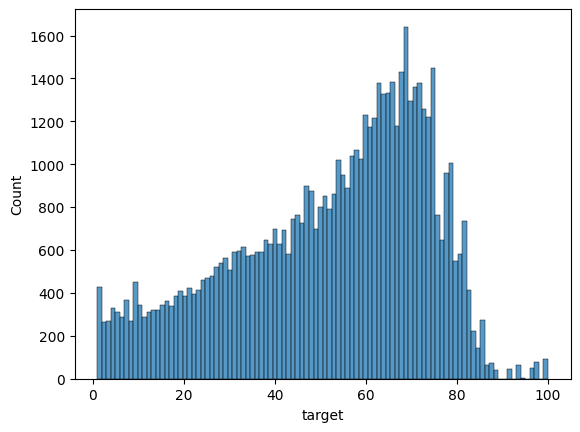

In [ ]:
sns.histplot(train_data['target'],bins = 100)

In [ ]:
train_data['publication_timestamp']

,publication_timestamp
0,2021-06-04
1,2019-07-01
2,2014-11-18
3,2015-09-25
4,2006-01-01
...,...
61604,2020-02-21
61605,2019-08-23
61606,2021-07-11
61607,2019-12-13


In [ ]:
#seperating publication_timestamp into year,month,day
train_data['publication_timestamp'] = pd.to_datetime(train_data['publication_timestamp'],errors='coerce')
test_data['publication_timestamp'] = pd.to_datetime(test_data['publication_timestamp'],errors='coerce')

train_data['year'] = train_data['publication_timestamp'].dt.year
train_data['month'] = train_data['publication_timestamp'].dt.month
train_data['day'] = train_data['publication_timestamp'].dt.day

test_data['year'] = test_data['publication_timestamp'].dt.year
test_data['month'] = test_data['publication_timestamp'].dt.month
test_data['day'] = test_data['publication_timestamp'].dt.day

min_date = train_data['publication_timestamp'].min()
train_data['days_since_start'] = (train_data['publication_timestamp'] - min_date).dt.days
test_data['days_since_start'] = (test_data['publication_timestamp'] - min_date).dt.days

train_data.drop('publication_timestamp',axis = 1,inplace = True)
test_data.drop('publication_timestamp',axis = 1,inplace = True)

In [ ]:
num_cols = train_data.select_dtypes(include = np.number).columns.drop(["id","target"])
cat_cols = train_data.select_dtypes(include = 'object').columns

In [ ]:
len(num_cols)+2 + len(cat_cols) == len(train_data.columns)

True

In [ ]:
#missing values handling
train_data[num_cols] = train_data[num_cols].fillna(train_data[num_cols].median())
train_data[cat_cols] = train_data[cat_cols].fillna(train_data[cat_cols].mode()).astype(str)

test_data[num_cols] = test_data[num_cols].fillna(train_data[num_cols].median())
test_data[cat_cols] = test_data[cat_cols].fillna(train_data[cat_cols].mode()).astype(str)

In [ ]:
num_cols_with_target = train_data.select_dtypes(include = np.number).columns

In [ ]:
len(num_cols_with_target)

57

In [ ]:
train_data[num_cols_with_target].dtypes

,0
id,int64
emotional_charge_2,float64
groove_efficiency_1,float64
beat_frequency_1,float64
organic_texture_2,float64
harmonic_scale_1,float64
intensity_index_0,float64
duration_ms_0,float64
album_name_length,float64
beat_frequency_0,float64


In [ ]:
correlation_matrix = train_data[num_cols_with_target].corr()
print(correlation_matrix)

                                  id  emotional_charge_2  groove_efficiency_1  \
id                          1.000000            0.000631            -0.002305   
emotional_charge_2          0.000631            1.000000             0.001098   
groove_efficiency_1        -0.002305            0.001098             1.000000   
beat_frequency_1            0.002415            0.082545            -0.052261   
organic_texture_2          -0.000905           -0.362486            -0.014174   
harmonic_scale_1           -0.002514            0.005854             0.005004   
intensity_index_0           0.003209            0.374779             0.030918   
duration_ms_0              -0.001985           -0.013882            -0.010716   
album_name_length          -0.004206           -0.063246             0.033219   
beat_frequency_0            0.001970            0.088177            -0.009382   
beat_frequency_2           -0.001231            0.137427             0.005800   
artist_count                

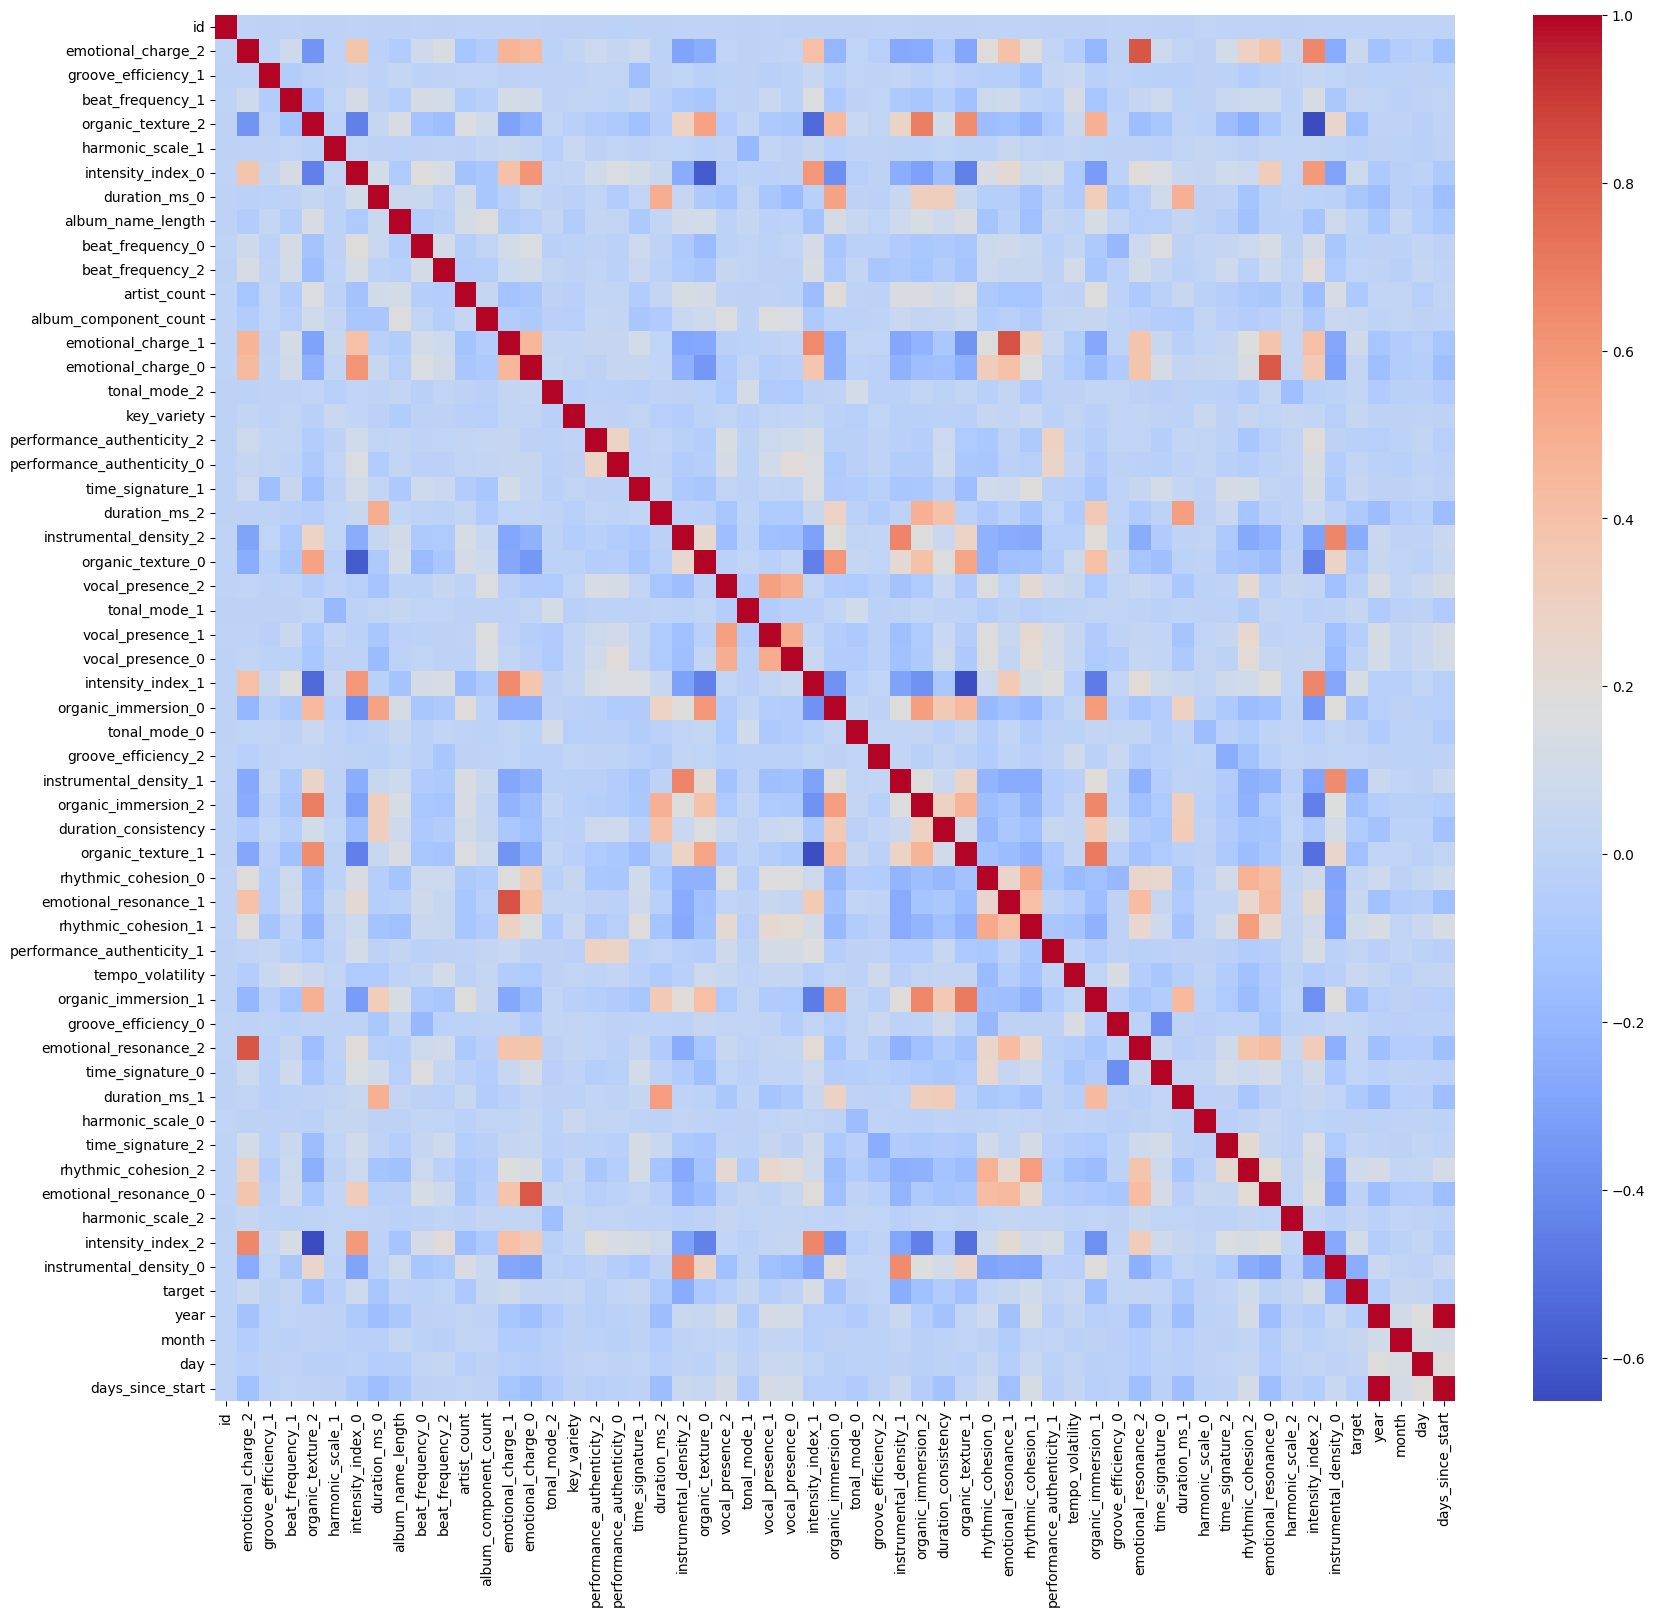

In [ ]:
plt.figure(figsize = (20,18))
sns.heatmap(train_data[num_cols_with_target].corr(),cmap = "coolwarm")
plt.show()

array([[<Axes: title={'center': 'emotional_charge_2'}>,
        <Axes: title={'center': 'groove_efficiency_1'}>,
        <Axes: title={'center': 'beat_frequency_1'}>,
        <Axes: title={'center': 'organic_texture_2'}>,
        <Axes: title={'center': 'harmonic_scale_1'}>,
        <Axes: title={'center': 'intensity_index_0'}>,
        <Axes: title={'center': 'duration_ms_0'}>],
       [<Axes: title={'center': 'album_name_length'}>,
        <Axes: title={'center': 'beat_frequency_0'}>,
        <Axes: title={'center': 'beat_frequency_2'}>,
        <Axes: title={'center': 'artist_count'}>,
        <Axes: title={'center': 'album_component_count'}>,
        <Axes: title={'center': 'emotional_charge_1'}>,
        <Axes: title={'center': 'emotional_charge_0'}>],
       [<Axes: title={'center': 'tonal_mode_2'}>,
        <Axes: title={'center': 'key_variety'}>,
        <Axes: title={'center': 'performance_authenticity_2'}>,
        <Axes: title={'center': 'performance_authenticity_0'}>,
     

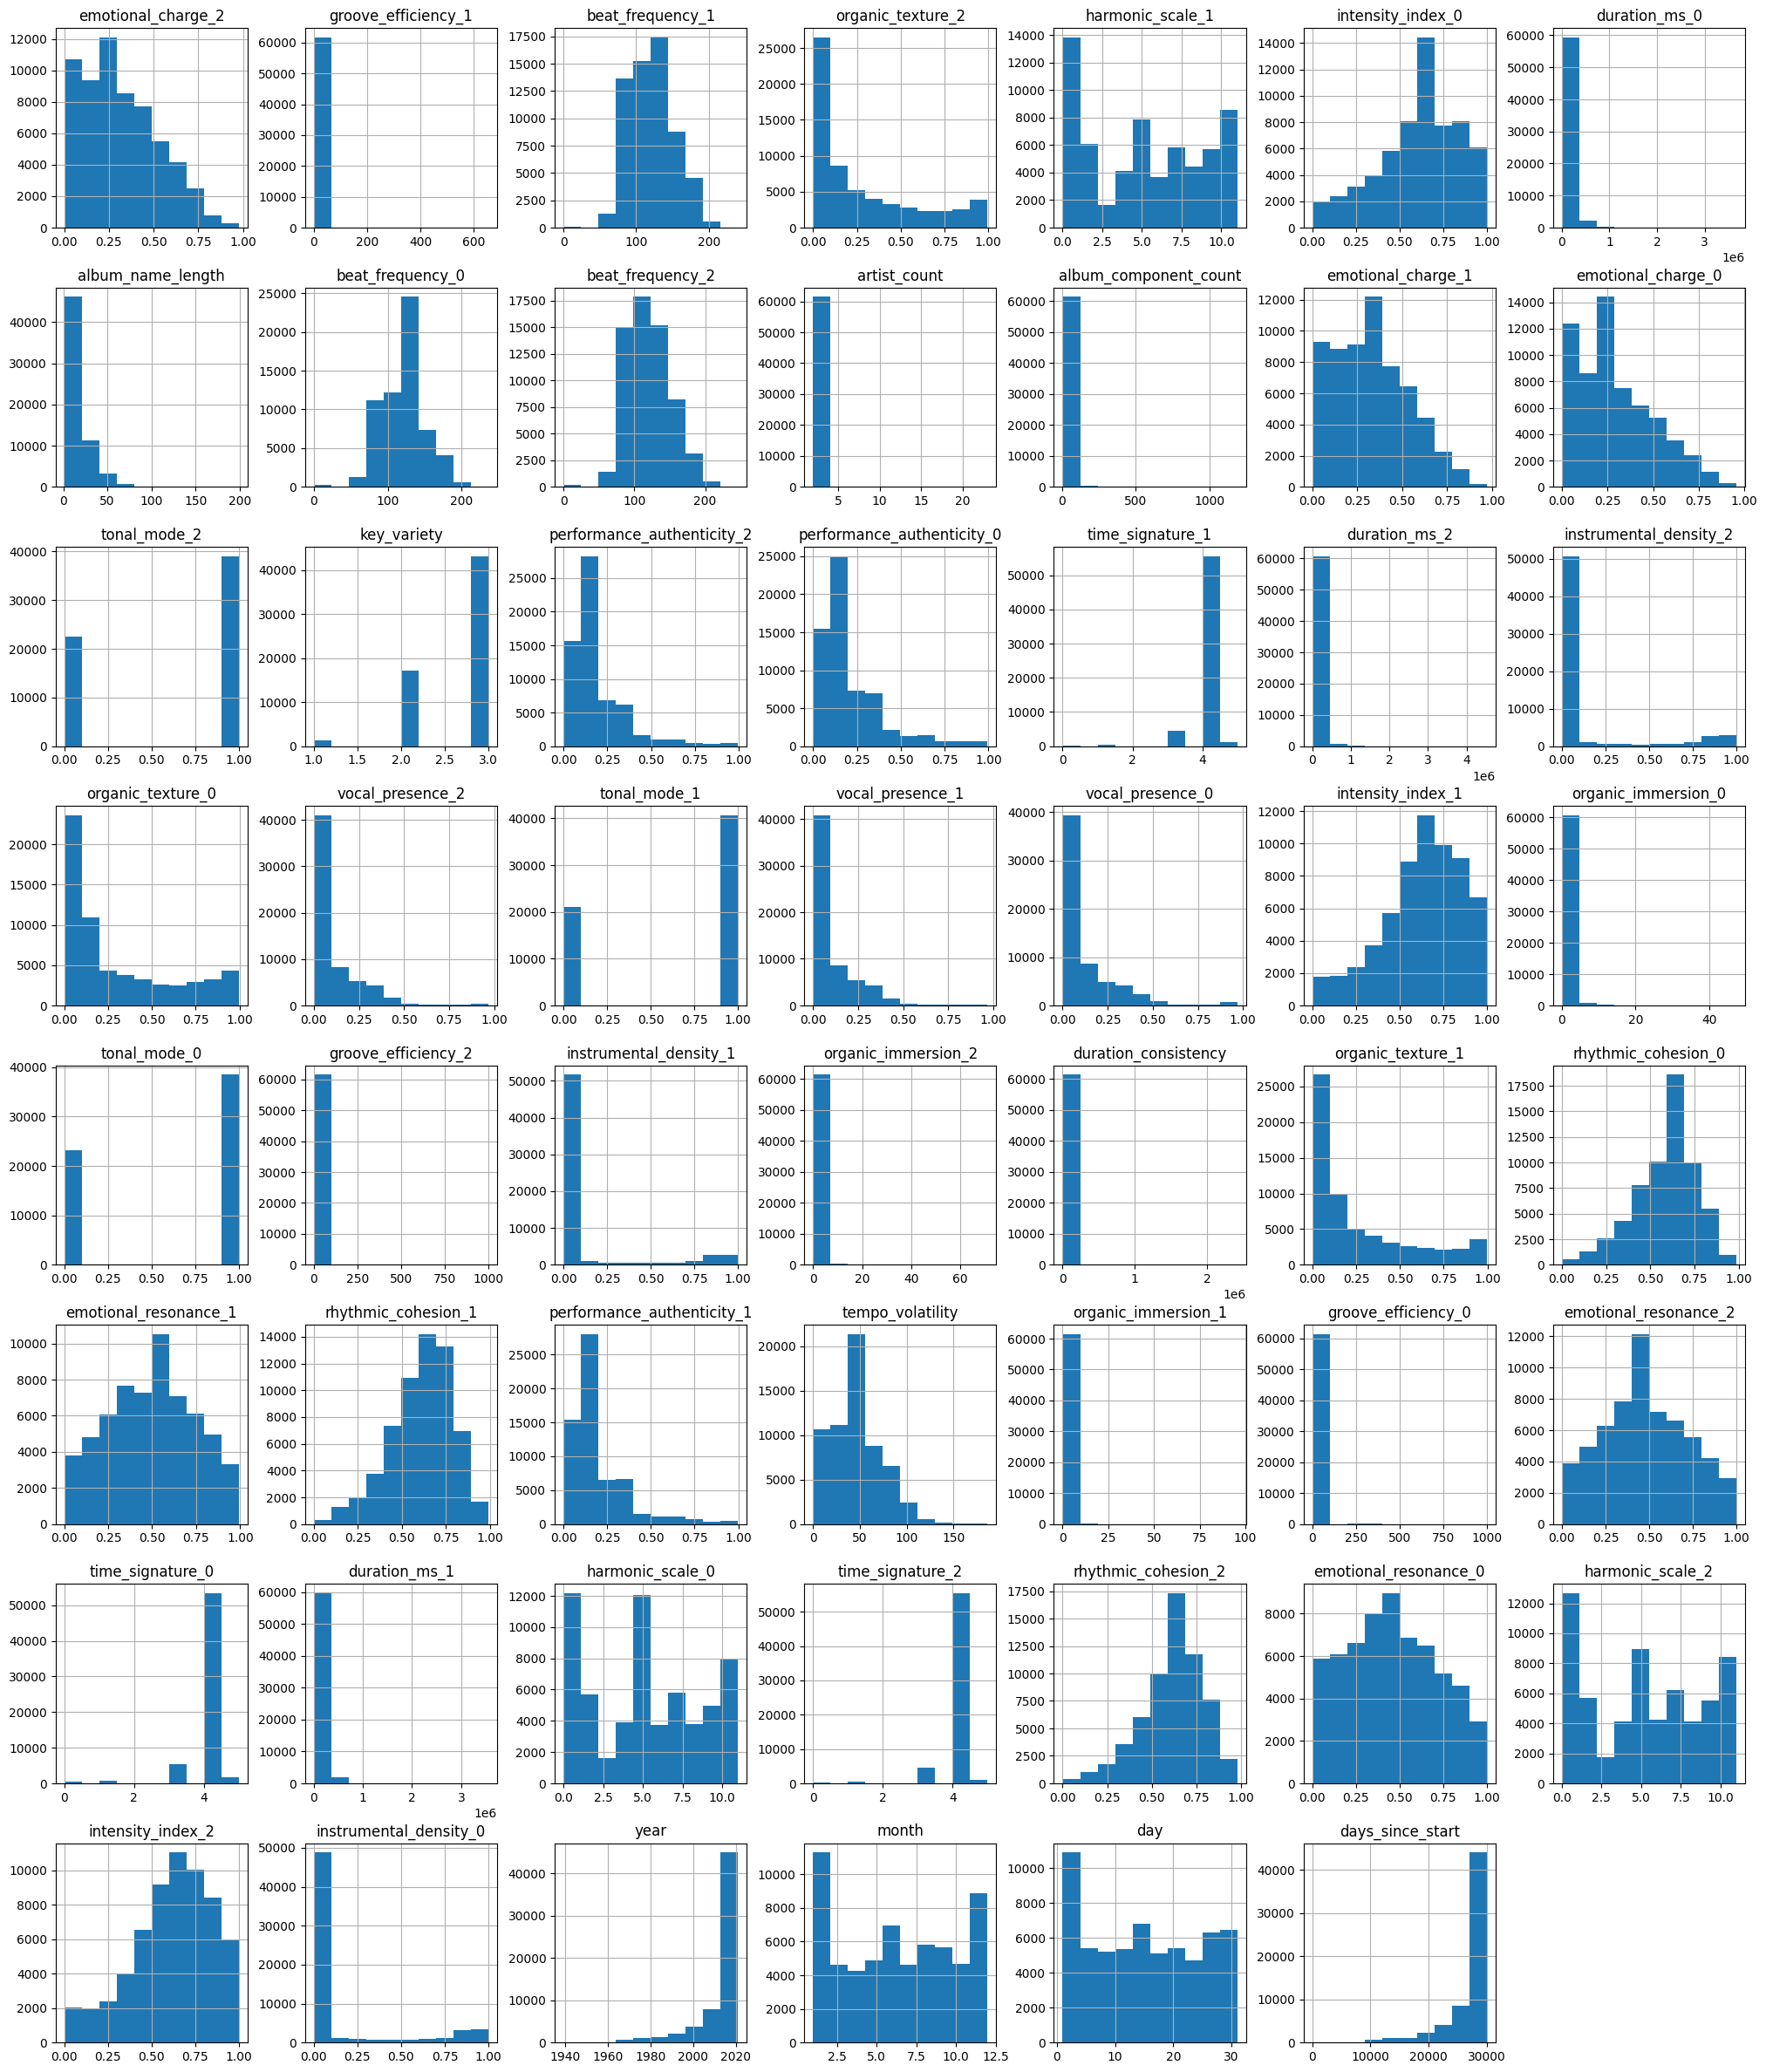

In [ ]:
train_data[num_cols].hist(figsize=(25,30))

In [ ]:
train_data.corr(numeric_only = True)['target'].sort_values(ascending = False)

,target
target,1.000000
intensity_index_1,0.131202
intensity_index_2,0.104390
rhythmic_cohesion_1,0.094959
rhythmic_cohesion_2,0.093436
emotional_charge_1,0.088034
intensity_index_0,0.077352
emotional_charge_2,0.061505
tempo_volatility,0.056473
emotional_resonance_1,0.051039


In [ ]:
#Feature selection
train_data[cat_cols].nunique().sort_values(ascending = False)

,0
track_identifier,22992
composition_label_1,22931
composition_label_2,22170
composition_label_0,21710
creator_collective,15140
weekday_of_release,8
season_of_release,5
lunar_phase,5


In [68]:
train_data[['track_identifier','composition_label_1','composition_label_0','composition_label_2','creator_collective']]

,track_identifier,composition_label_1,composition_label_0,composition_label_2,creator_collective
0,Certified Lover Boy,Fancy Like,Country Stuff (feat. Jake Owen),Even Though I'm Leaving,"Walker Hayes,"
1,BornTo DieAlone,TryHard,Solitude,WontYouSaveMe,"Zpvrt,"
2,BDFFRNT,Wow,BDFFRNT (Saved from Conformity),nan,"Dillon Chase,"
3,Sugar,Sugar (feat. Francesco Yates),Headlights (feat. Ilsey),Heatwave (feat. Akon),nan
4,Loose,Maneater,Afraid,Promiscuous Interlude,"Nelly Furtado,"
...,...,...,...,...,...
61604,"Aykut Gürel Presents Bergüzar Korel, Vol. 2",Yarına Allah Kerim,Hasret,nan,"Bergüzar Korel,"
61605,GINGER,SUGAR,NO HALO,BOY BYE,"BROCKHAMPTON,"
61606,The White Lotus (Soundtrack from the HBO® Orig...,Pineapple Suite,Aloha! - Main Title Theme,Jungle Fever,"Cristobal Tapia De Veer,"
61607,Fine Line,Watermelon Sugar,Golden,Adore You,"Harry Styles,"


In [78]:
cat_cols_to_drop = ['track_identifier','composition_label_1','composition_label_0','composition_label_2','creator_collective']
#Since these features mostly contain text like data over 15000 non unique values in columns decided to drop these

In [79]:
num_cols

Index(['emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1',
       'organic_texture_2', 'harmonic_scale_1', 'intensity_index_0',
       'duration_ms_0', 'album_name_length', 'beat_frequency_0',
       'beat_frequency_2', 'artist_count', 'album_component_count',
       'emotional_charge_1', 'emotional_charge_0', 'tonal_mode_2',
       'key_variety', 'performance_authenticity_2',
       'performance_authenticity_0', 'time_signature_1', 'duration_ms_2',
       'instrumental_density_2', 'organic_texture_0', 'vocal_presence_2',
       'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0',
       'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0',
       'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2',
       'duration_consistency', 'organic_texture_1', 'rhythmic_cohesion_0',
       'emotional_resonance_1', 'rhythmic_cohesion_1',
       'performance_authenticity_1', 'tempo_volatility', 'organic_immersion_1',
       'groove_efficiency_0', 'emotional

In [53]:
#using RandomForest for feature importance identification
X = train_data[num_cols]
y = train_data['target']

feature_selection_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

feature_selection_model.fit(X,y)


RandomForestRegressor(random_state=42)

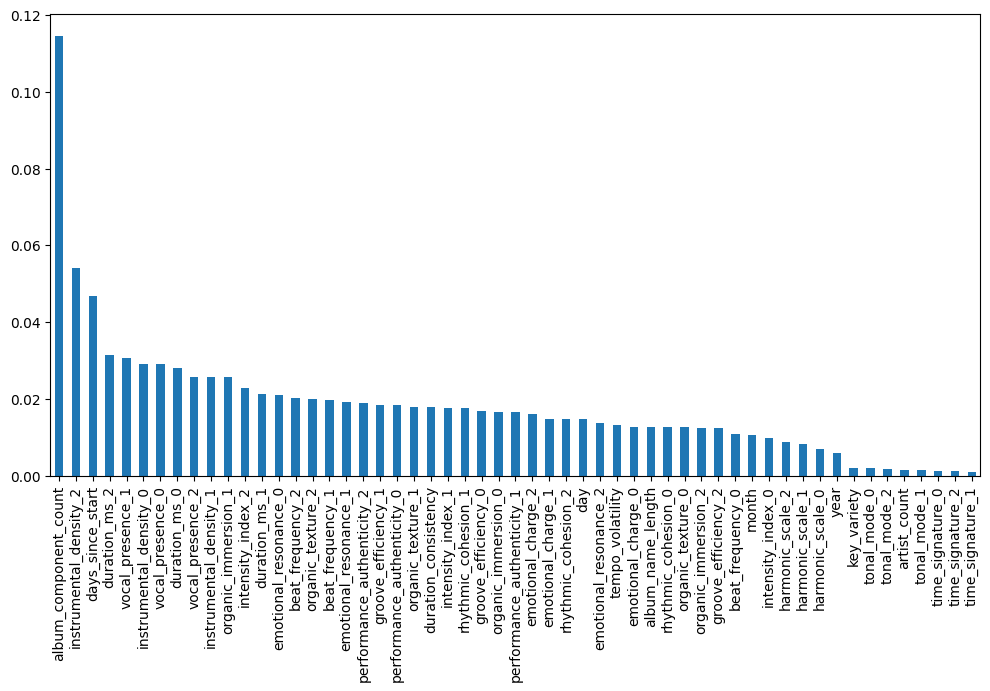

In [80]:
feature_importances = pd.Series(feature_selection_model.feature_importances_,index = X.columns)
feature_importances.sort_values(ascending = False).plot(kind = 'bar',figsize = (12,6))
plt.show()

In [81]:
num_cols_to_drop = ['key_variety','tonal_mode_0','tonal_mode_2','artist_count','tonal_mode_1','time_signature_0','time_signature_2','time_signature_1']

In [82]:
#checking for multicollinearity
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
drop_cols = [column for column in upper.columns if any(upper[column] > 0.95)]
print(drop_cols)

high_corr_pairs ={}
for col in drop_cols:
  high_corr = upper.index[upper[col] > 0.95].tolist()
  high_corr_pairs[col] = high_corr

print("Highly correlated features with corresponding drop column")
for col,corr_cols in high_corr_pairs.items():
  print(f"{col} : {corr_cols}")

['days_since_start']
Highly correlated features with corresponding drop column
days_since_start : ['year']


In [83]:
#since "days_since_start" has a higher feature importance than "year", drop "year"
num_cols_to_drop.append('year')

In [84]:
print(num_cols_to_drop)
print(cat_cols_to_drop)

['key_variety', 'tonal_mode_0', 'tonal_mode_2', 'artist_count', 'tonal_mode_1', 'time_signature_0', 'time_signature_2', 'time_signature_1', 'year']
['track_identifier', 'composition_label_1', 'composition_label_0', 'composition_label_2', 'creator_collective']


In [85]:
final_num_cols = [col for col in num_cols if col not in num_cols_to_drop]
final_cat_cols = [col for col in cat_cols if col not in cat_cols_to_drop]

In [86]:
print(final_num_cols)
print(final_cat_cols)

['emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1', 'organic_texture_2', 'harmonic_scale_1', 'intensity_index_0', 'duration_ms_0', 'album_name_length', 'beat_frequency_0', 'beat_frequency_2', 'album_component_count', 'emotional_charge_1', 'emotional_charge_0', 'performance_authenticity_2', 'performance_authenticity_0', 'duration_ms_2', 'instrumental_density_2', 'organic_texture_0', 'vocal_presence_2', 'vocal_presence_1', 'vocal_presence_0', 'intensity_index_1', 'organic_immersion_0', 'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2', 'duration_consistency', 'organic_texture_1', 'rhythmic_cohesion_0', 'emotional_resonance_1', 'rhythmic_cohesion_1', 'performance_authenticity_1', 'tempo_volatility', 'organic_immersion_1', 'groove_efficiency_0', 'emotional_resonance_2', 'duration_ms_1', 'harmonic_scale_0', 'rhythmic_cohesion_2', 'emotional_resonance_0', 'harmonic_scale_2', 'intensity_index_2', 'instrumental_density_0', 'month', 'day', 'days_since_start']


In [87]:
#encoding
onehotencoder = OneHotEncoder(handle_unknown = 'ignore',sparse_output = False)
encoded_train_data = onehotencoder.fit_transform(train_data[final_cat_cols])
encoded_test_data = onehotencoder.transform(test_data[final_cat_cols])


encoded_cols = onehotencoder.get_feature_names_out(final_cat_cols)
encoded_train_df = pd.DataFrame(encoded_train_data,columns = encoded_cols,index = train_data.index)

array([[1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])